In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno

In [24]:
ecommerce_retail = pd.read_excel(r"D:\\Unigap\\Final_project_RFM\\ecommerce retail.xlsx")
ecommerce_retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
ecommerce_retail.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [4]:
ecommerce_retail.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [5]:
ecommerce_retail.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## **1) Data Preprocessing + EDA**

In [ ]:
# Convert to correct data types
column_list = ["InvoiceNo", "StockCode", "Description", "CustomerID", "Country"]

for col in column_list:
    ecommerce_retail[col] = ecommerce_retail[col].astype(str)

ecommerce_retail["InvoiceDate"] = pd.to_datetime(ecommerce_retail["InvoiceDate"], errors="coerce")
print(ecommerce_retail[column_list + ["InvoiceDate"]].dtypes)

InvoiceNo                 str
StockCode                 str
Description               str
CustomerID                str
Country                   str
InvoiceDate    datetime64[us]
dtype: object


In [ ]:
# Remove invalid transactions using business rules
rows_before_rules = len(ecommerce_retail)

mask_cancel = ecommerce_retail["InvoiceNo"].str.startswith("C", na=False)
mask_negative_qty = ecommerce_retail["Quantity"] < 0
mask_negative_price = ecommerce_retail["UnitPrice"] < 0

desc_norm = ecommerce_retail["Description"].str.strip().str.lower()
mask_invalid_desc = desc_norm.isin(["nan", "", "none", "?", "??", "???"] )

removed_cancel = mask_cancel.sum()
removed_negative_qty = (mask_negative_qty & ~mask_cancel).sum()
removed_negative_price = mask_negative_price.sum()
removed_invalid_desc = mask_invalid_desc.sum()

ecommerce_retail = ecommerce_retail.loc[~mask_cancel].copy()
ecommerce_retail = ecommerce_retail.loc[ecommerce_retail["Quantity"] > 0].copy()
ecommerce_retail = ecommerce_retail.loc[ecommerce_retail["UnitPrice"] > 0].copy()
ecommerce_retail = ecommerce_retail.loc[~mask_invalid_desc.reindex(ecommerce_retail.index, fill_value=False)].copy()

print(f"Rows before rule-based cleaning: {rows_before_rules:,}")
print(f"Canceled invoices removed: {removed_cancel:,}")
print(f"Negative quantity (non-cancel) removed: {removed_negative_qty:,}")
print(f"Negative unit price removed: {removed_negative_price:,}")
print(f"Incorrect descriptions removed: {removed_invalid_desc:,}")
print(f"Rows after rule-based cleaning: {len(ecommerce_retail):,}")

Rows before rule-based cleaning: 541,909
Canceled invoices removed: 9,288
Negative quantity (non-cancel) removed: 1,336
Negative unit price removed: 2
Incorrect descriptions removed: 55
Rows after rule-based cleaning: 530,104


<Axes: >

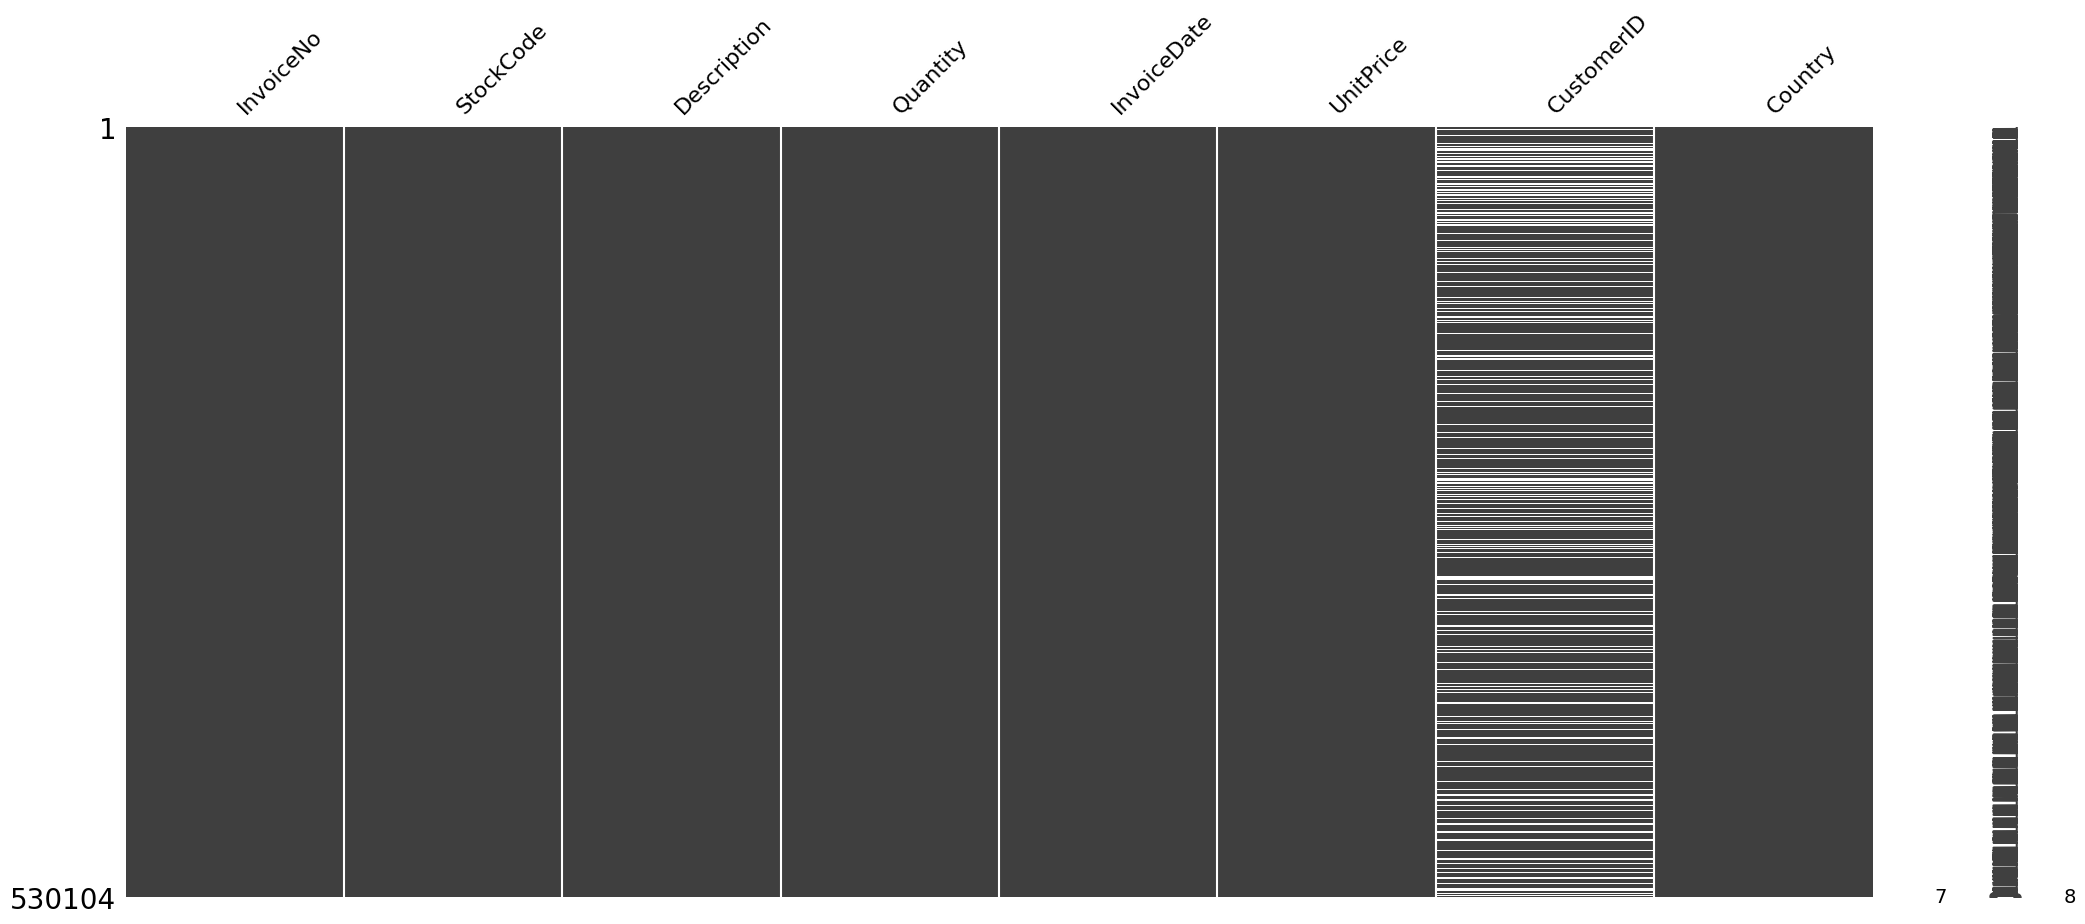

In [ ]:
# Visualize missing values
msno.matrix(ecommerce_retail)

In [27]:
# Standardize missing formats in CustomerID
ecommerce_retail["CustomerID"] = ecommerce_retail["CustomerID"].replace(["nan", "", " "], np.nan)

missing_summary = pd.DataFrame({
    "volume": ecommerce_retail.isnull().sum(),
    "%": (ecommerce_retail.isnull().sum() / ecommerce_retail.shape[0]) * 100,
})

missing_summary.sort_values("volume", ascending=False)

,volume,%
CustomerID,132220,24.942275
InvoiceNo,0,0.000000
Description,0,0.000000
StockCode,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
Country,0,0.000000


In [10]:
# Quick investigation of missing CustomerID distribution
missing_customerid = ecommerce_retail[ecommerce_retail["CustomerID"].isna()].copy()
missing_country = missing_customerid["Country"].value_counts().head(10)
missing_month = missing_customerid["InvoiceDate"].dt.to_period("M").value_counts().sort_index()

print(f"Missing CustomerID rows: {len(missing_customerid):,}")
print("\nTop countries (missing CustomerID):")
print(missing_country)
print("\nMonthly distribution (missing CustomerID):")
print(missing_month.tail(12))

Missing CustomerID rows: 132,220

Top countries (missing CustomerID):
Country
United Kingdom    130802
EIRE                 654
Hong Kong            284
Unspecified          202
Switzerland          125
France                66
Israel                47
Portugal              39
Bahrain                1
Name: count, dtype: int64

Monthly distribution (missing CustomerID):
InvoiceDate
2011-01    13077
2011-02     7178
2011-03     8628
2011-04     6454
2011-05     7844
2011-06     8792
2011-07    11820
2011-08     7476
2011-09     9233
2011-10     9750
2011-11    18838
2011-12     7807
Freq: M, Name: count, dtype: int64


In [28]:
# Final decision: remove rows without valid CustomerID
rows_before_customerid = len(ecommerce_retail)
ecommerce_retail = ecommerce_retail.dropna(subset=["CustomerID"]).copy()

print(f"Rows before dropping missing CustomerID: {rows_before_customerid:,}")
print(f"Rows after dropping missing CustomerID: {len(ecommerce_retail):,}")

Rows before dropping missing CustomerID: 530,104
Rows after dropping missing CustomerID: 397,884


In [ ]:
# Identify duplicate records
duplicate_keys = ["InvoiceNo", "StockCode", "InvoiceDate", "CustomerID"]
ecommerce_duplicate = ecommerce_retail[
    ecommerce_retail.duplicated(subset=duplicate_keys, keep=False)
] .copy()

print(f"Duplicate rows detected (by key set): {len(ecommerce_duplicate):,}")
ecommerce_duplicate.head()

Duplicate rows detected (by key set): 19,148


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
113,536381,71270,PHOTO CLIP LINE,1,2010-12-01 09:41:00,1.25,15311.0,United Kingdom
125,536381,71270,PHOTO CLIP LINE,3,2010-12-01 09:41:00,1.25,15311.0,United Kingdom
483,536409,90199C,5 STRAND GLASS NECKLACE CRYSTAL,3,2010-12-01 11:45:00,6.35,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom


In [ ]:
# Print exact duplicates (all fields identical)
exact_dup_keys = duplicate_keys + ["Quantity", "UnitPrice", "Description", "Country"]
exact_duplicate_rows = ecommerce_retail[
    ecommerce_retail.duplicated(subset=exact_dup_keys, keep=False)
] .copy()

print(f"Exact duplicate rows: {len(exact_duplicate_rows):,}")
exact_duplicate_rows.head(10)

Exact duplicate rows: 10,001


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
548,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


In [ ]:
# Print potential split duplicates (same transaction key, different quantities)
duplicate_key_rows = ecommerce_retail[
    ecommerce_retail.duplicated(subset=duplicate_keys, keep=False)
] .copy()

if duplicate_key_rows.empty:
    print("No duplicate transaction keys found.")
    split_groups = pd.DataFrame()
else:
    split_groups = (
        duplicate_key_rows.groupby(duplicate_keys)
        .agg(
            row_count=("Quantity", "size"),
            qty_nunique=("Quantity", "nunique"),
            qty_values=("Quantity", lambda s: sorted(s.unique().tolist())),
        )
        .reset_index()
    )
    split_groups = split_groups[split_groups["qty_nunique"] > 1].sort_values(
        "row_count", ascending=False
    )

print(f"Duplicate rows by transaction key: {len(duplicate_key_rows):,}")
print(f"Potential split groups (qty_nunique > 1): {len(split_groups):,}")
split_groups.head(10)

Duplicate rows by transaction key: 19,148
Potential split groups (qty_nunique > 1): 4,660


,InvoiceNo,StockCode,InvoiceDate,CustomerID,row_count,qty_nunique,qty_values
5789,572344,M,2011-10-24 10:43:00,14607.0,7,2,"[48, 456]"
7936,578289,23395,2011-11-23 14:07:00,17841.0,7,2,"[1, 12]"
6376,574481,23084,2011-11-04 12:45:00,18022.0,6,2,"[1, 4]"
7,536412,21448,2010-12-01 11:49:00,17920.0,5,2,"[1, 2]"
2915,555853,22161,2011-06-07 13:44:00,14375.0,5,3,"[1, 4, 5]"
1426,544463,22256,2011-02-20 14:31:00,12988.0,5,2,"[1, 2]"
6880,575753,47422,2011-11-11 10:41:00,17841.0,5,2,"[1, 4]"
408,537646,22585,2010-12-07 15:39:00,17591.0,5,3,"[1, 2, 3]"
1599,545658,16237,2011-03-04 14:13:00,14670.0,5,3,"[1, 2, 3]"
5286,571039,21034,2011-10-13 12:59:00,16121.0,5,3,"[1, 3, 5]"


In [ ]:
# Duplicate summary for reporting (no handling applied)
dup_key_count = ecommerce_retail.duplicated(subset=duplicate_keys, keep=False).sum()
exact_dup_count = ecommerce_retail.duplicated(subset=exact_dup_keys, keep=False).sum()

print(f"Total rows in current dataset: {len(ecommerce_retail):,}")
print(f"Rows involved in transaction-key duplicates: {dup_key_count:,}")
print(f"Rows involved in exact duplicates: {exact_dup_count:,}")

Total rows in current dataset: 397,884
Rows involved in transaction-key duplicates: 19,148
Rows involved in exact duplicates: 10,001


### Duplicate Handling
When duplicate records are detected, they are resolved under two rule-based scenarios to ensure data integrity and preserve revenue accuracy.

**Case 1: Identical Duplicates**
Definition: same `InvoiceNo`, `StockCode`, `CustomerID`, `InvoiceDate`, and `Quantity`.
Interpretation: likely generated by system-level duplication.
Action: remove duplicate rows.

**Case 2: Same Transaction with Different Quantities**
Definition: same `InvoiceNo` and `StockCode`, but recorded in separate rows with different `Quantity` values.
Interpretation: likely caused by transaction split at order-line level.
Action: aggregate `Quantity` for each transaction-product combination to maintain accurate revenue calculation.

In [ ]:
# Datatype standardization before RFM
ecommerce_retail = ecommerce_retail.astype({
    "InvoiceNo": "str",
    "StockCode": "str",
    "Description": "str",
    "CustomerID": "str",
    "Country": "str",
})

ecommerce_retail.info()

<class 'pandas.DataFrame'>
RangeIndex: 387846 entries, 0 to 387845
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    387846 non-null  str           
 1   StockCode    387846 non-null  str           
 2   Description  387846 non-null  str           
 3   Quantity     387846 non-null  int64         
 4   InvoiceDate  387846 non-null  datetime64[us]
 5   UnitPrice    387846 non-null  float64       
 6   CustomerID   387846 non-null  str           
 7   Country      387846 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(5)
memory usage: 23.7 MB


## **2) RFM Metric Calculation**
Calculate Recency, Frequency, and Monetary for each customer.

## **3) RFM Scoring (Quintile 1-5)**
Convert each metric into a 1-5 score using quintiles.
Reference date for Recency: 2011-12-31.

In [33]:
# Calculate revenue
ecommerce_retail["Revenue"] = ecommerce_retail["Quantity"] * ecommerce_retail["UnitPrice"]

# Date to calculate recency
reference_date = pd.to_datetime("2011-12-31")

rfm = ecommerce_retail.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum",
}).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

# Divide Recency into 5 quintiles (5->1, Min is the best)
rfm["R"] = pd.qcut(rfm["Recency"], q=5, labels=[5, 4, 3, 2, 1], duplicates="drop")

# Divide Frequency into 5 quintiles (1->5, Max is the best)
rfm["F"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop",
)

# Divide Monetary into 5 quintiles (1->5, Max is the best)
rfm["M"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop",
)

rfm["RFM_scores"] = rfm["R"].astype(str) + rfm["F"].astype(str) + rfm["M"].astype(str)
print(rfm.head())
print(f"\nRecency range: {rfm['Recency'].min()} - {rfm['Recency'].max()} days")

  CustomerID  Recency  Frequency  Monetary  R  F  M RFM_scores
0    12346.0      346          1  77183.60  1  1  5        115
1    12347.0       23          7   4310.00  5  5  5        555
2    12348.0       96          4   1797.24  2  4  4        244
3    12349.0       39          1   1757.55  4  1  4        414
4    12350.0      331          1    334.40  1  1  2        112

Recency range: 21 - 394 days


## **4) Customer Segmentation Mapping**

In [ ]:
segment_map = {
    'Champions': ['555','554','544','545','454','455','445'],
    'Loyal': ['543','444','435','355','354','345','344','335'],
    'Potential Loyalist': ['553','551','552','541','542','533','532','531',
                           '452','451','442','441','431','453','433','432',
                           '423','353','352','351','342','341','333','323'],
    'New Customers': ['512','511','422','421','412','411','311'],
    'Promising': ['525','524','523','522','521','515','514','513',
                  '425','424','413','414','415','315','314','313'],
    'Need Attention': ['535','534','443','434','343','334','325','324'],
    'About To Sleep': ['331','321','312','221','213','231','241','251'],
    'At Risk': ['255','254','245','244','253','252','243','242','235','234',
               '225','224','153','152','145','143','142','135','134','133',
               '125','124'],
    'Cannot Lose Them': ['155','154','144','214','215','115','114','113'],
    'Hibernating customers': ['332','322','233','232','223','222','132','123',
                             '122','212','211'],
    'Lost customers': ['111','112','121','131','141','151']
}

# Reverse map: RFM_score -> Segment
rfm_to_segment = {score: seg for seg, scores in segment_map.items() for score in scores}

rfm['Segment'] = rfm['RFM_scores'].map(rfm_to_segment).fillna('Others')

rfm

,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM_scores,Segment
0,12346.0,346,1,77183.60,1,1,5,115,Cannot Lose Them
1,12347.0,23,7,4310.00,5,5,5,555,Champions
2,12348.0,96,4,1797.24,2,4,4,244,At Risk
3,12349.0,39,1,1757.55,4,1,4,414,Promising
4,12350.0,331,1,334.40,1,1,2,112,Lost customers
...,...,...,...,...,...,...,...,...,...
4333,18280.0,298,1,180.60,1,2,1,121,Lost customers
4334,18281.0,201,1,80.82,1,2,1,121,Lost customers
4335,18282.0,28,2,178.05,5,3,1,531,Potential Loyalist
4336,18283.0,24,16,2045.53,5,5,4,554,Champions


In [20]:
ecommerce_retail["Segment"] = ecommerce_retail["CustomerID"].map(
    rfm.set_index("CustomerID")["Segment"]
)
ecommerce_retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Segment
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,Cannot Lose Them
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Cannot Lose Them
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,Cannot Lose Them
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Cannot Lose Them
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Cannot Lose Them


## **5) Segment Visualization**

### Chart 1 - Customer Count by Segment
Distribution of customers across segments to assess audience size within each behavioral group.

Segment
Champions                834
Hibernating customers    693
Lost customers           485
Loyal                    426
At Risk                  423
Potential Loyalist       411
Need Attention           287
About To Sleep           286
New Customers            268
Promising                133
Cannot Lose Them          92
Name: count, dtype: int64


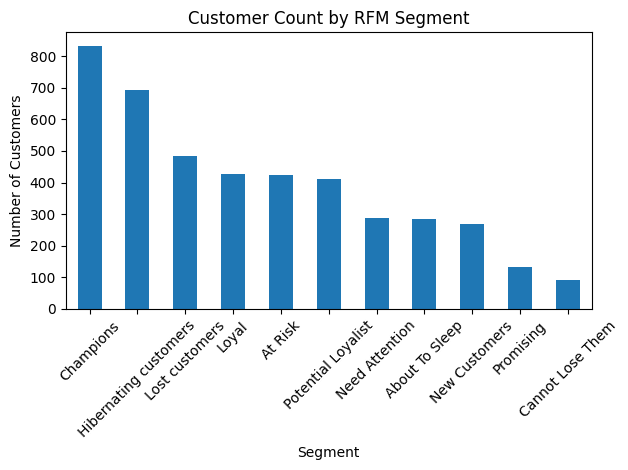

In [21]:
segment_counts = rfm["Segment"].value_counts()
print(segment_counts)

segment_counts.plot(kind="bar")
plt.title("Customer Count by RFM Segment")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Key Insight**
- The customer base is concentrated in a few large segments, showing where the company has the strongest campaign reach.
- Smaller segments represent narrower but potentially higher-value audiences that should not be managed like mass-market groups.
-> Marketing action: Use the largest segments for broad campaign testing and awareness programs, while assigning personalized CRM flows to smaller high-value segments.

### Chart 2 - Revenue by Segment
Revenue distribution by segment to identify the groups that generate the highest financial value.

Segment
Champions                5591628.710
Loyal                    1015451.640
At Risk                   750634.391
Need Attention            467188.591
Hibernating customers     282751.372
Potential Loyalist        221408.990
Cannot Lose Them          204036.680
Promising                 119099.520
Lost customers             96590.980
About To Sleep             78743.090
New Customers              59674.930
Name: Monetary, dtype: float64


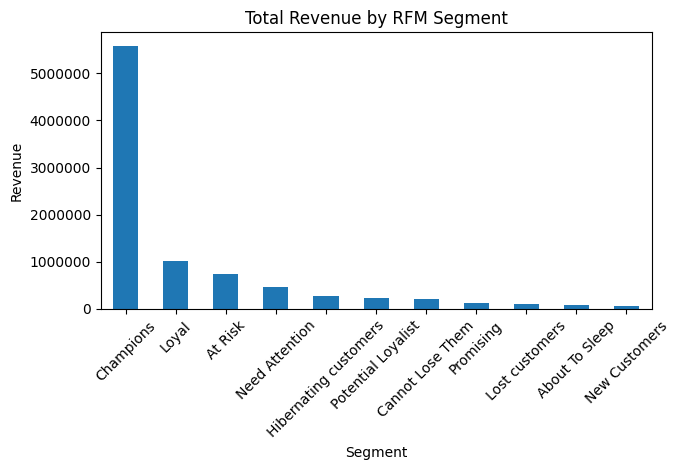

In [22]:
rev_by_segment = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)
print(rev_by_segment)

rev_by_segment.plot(kind="bar")
plt.title("Total Revenue by RFM Segment")
plt.xlabel("Segment")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.ticklabel_format(style="plain", axis="y")
plt.show()

**Key Insight**
- Revenue is concentrated in a limited number of segments, meaning the company's performance depends heavily on a few high-value customer groups.
- Some segments may be large in size but still weak in revenue contribution, which signals monetization inefficiency.<br>
-> Marketing action: Prioritize retention, upsell, and VIP treatment for top-revenue segments, and run basket-growth campaigns for large but lower-revenue groups.

### Extended RFM Visualization Pack
The charts below provide a broader RFM view, including metric distributions, score distributions, correlation heatmaps, score matrices, segment mix, revenue Pareto analysis, customer behavior bubbles, segment profiles, and monthly trends.

In [37]:
from matplotlib.ticker import PercentFormatter

# Ensure segment labels exist even when cells are executed out of order
if "Segment" not in rfm.columns:
    if "rfm_to_segment" in globals():
        rfm["Segment"] = rfm["RFM_scores"].map(rfm_to_segment).fillna("Others")
    elif "segment_map" in globals():
        _rfm_to_segment = {score: seg for seg, scores in segment_map.items() for score in scores}
        rfm["Segment"] = rfm["RFM_scores"].map(_rfm_to_segment).fillna("Others")
    else:
        rfm["Segment"] = "Others"

if "Segment" not in ecommerce_retail.columns:
    segment_lookup = rfm.set_index("CustomerID")["Segment"]
    ecommerce_retail["Segment"] = ecommerce_retail["CustomerID"].map(segment_lookup).fillna("Others")

# Shared data for visualization cells
rfm_viz = rfm.copy()
for metric in ["R", "F", "M"]:
    rfm_viz[metric] = rfm_viz[metric].astype(int)

rfm_viz["Segment"] = rfm_viz["Segment"].fillna("Others")
rfm_viz["FM_Score"] = ((rfm_viz["F"] + rfm_viz["M"]) / 2).round().astype(int)
rfm_viz["Monetary_log1p"] = np.log1p(rfm_viz["Monetary"] )
score_levels = [1, 2, 3, 4, 5]

def draw_annotated_heatmap(ax, matrix, title, x_label, y_label, cmap="YlGnBu", fmt=",.0f"):
    im = ax.imshow(matrix.values, cmap=cmap, aspect="auto", origin="lower")
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_xticks(np.arange(len(matrix.columns)))
    ax.set_yticks(np.arange(len(matrix.index)))
    ax.set_xticklabels(matrix.columns)
    ax.set_yticklabels(matrix.index)
    for row_idx in range(matrix.shape[0]):
        for col_idx in range(matrix.shape[1]):
            value = matrix.iat[row_idx, col_idx]
            ax.text(col_idx, row_idx, format(value, fmt), ha="center", va="center", fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

print(f"Visualization readiness check completed for {len(rfm_viz):,} customers.")

Visualization readiness check completed for 4,338 customers.


### Chart 3 - Distribution of Core RFM Metrics
Histograms and boxplots for Recency, Frequency, and Monetary to evaluate skewness and value concentration across the customer base.

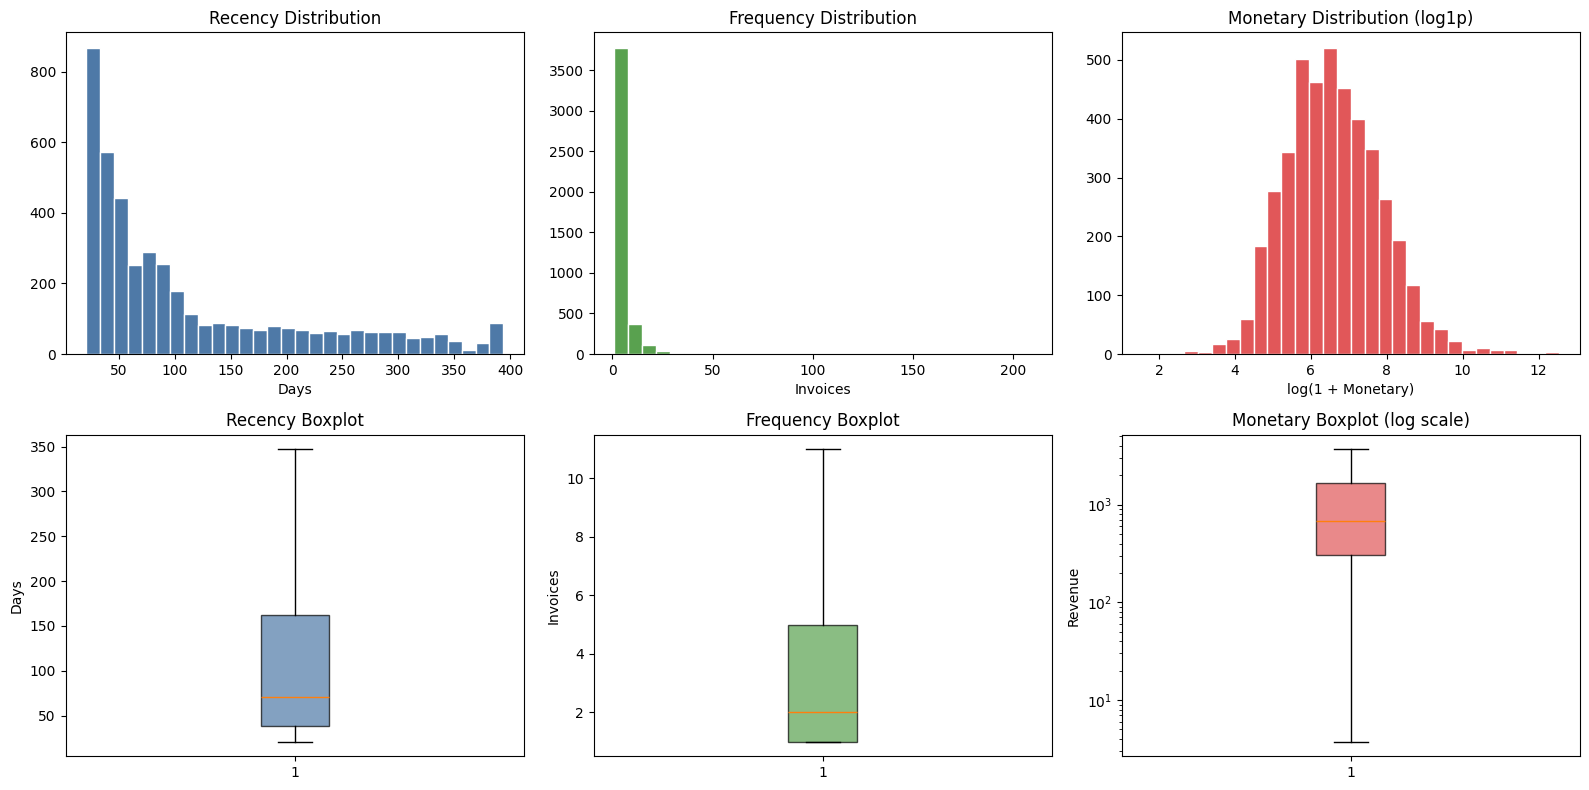

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].hist(rfm_viz["Recency"], bins=30, color="#4E79A7", edgecolor="white")
axes[0, 0].set_title("Recency Distribution")
axes[0, 0].set_xlabel("Days")

axes[0, 1].hist(rfm_viz["Frequency"], bins=30, color="#59A14F", edgecolor="white")
axes[0, 1].set_title("Frequency Distribution")
axes[0, 1].set_xlabel("Invoices")

axes[0, 2].hist(rfm_viz["Monetary_log1p"], bins=30, color="#E15759", edgecolor="white")
axes[0, 2].set_title("Monetary Distribution (log1p)")
axes[0, 2].set_xlabel("log(1 + Monetary)")

axes[1, 0].boxplot(
    rfm_viz["Recency"],
    vert=True,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="#4E79A7", alpha=0.7),
)
axes[1, 0].set_title("Recency Boxplot")
axes[1, 0].set_ylabel("Days")

axes[1, 1].boxplot(
    rfm_viz["Frequency"],
    vert=True,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="#59A14F", alpha=0.7),
)
axes[1, 1].set_title("Frequency Boxplot")
axes[1, 1].set_ylabel("Invoices")

axes[1, 2].boxplot(
    rfm_viz["Monetary"],
    vert=True,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="#E15759", alpha=0.7),
)
axes[1, 2].set_title("Monetary Boxplot (log scale)")
axes[1, 2].set_yscale("log")
axes[1, 2].set_ylabel("Revenue")

plt.tight_layout()
plt.show()

**Key Insight**
- Most customers buy infrequently and spend at relatively low levels, while a small portion generates a disproportionate share of revenue.
- Recency is widely spread, showing that the company is managing both recently active and long-inactive customers at the same time.<br>
-> Marketing action: Separate CRM into win-back journeys for inactive customers and retention tiers for frequent high-spend customers.

### Chart 4 - RFM Score Distribution
Distribution of R, F, and M scores across quintiles to verify score balance across the customer base.

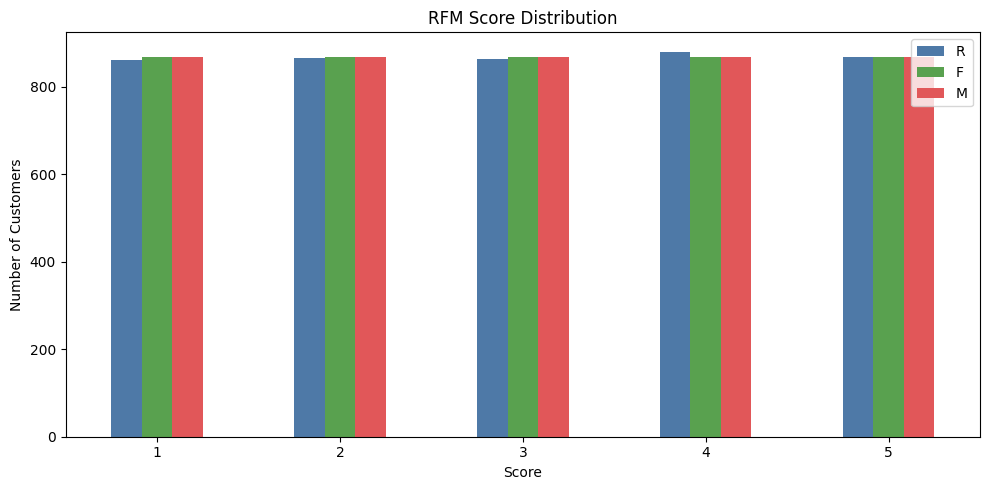

In [39]:
score_distribution = pd.DataFrame({
    "R": rfm_viz["R"].value_counts().sort_index(),
    "F": rfm_viz["F"].value_counts().sort_index(),
    "M": rfm_viz["M"].value_counts().sort_index(),
}).fillna(0).astype(int)

score_distribution.plot(kind="bar", figsize=(10, 5), color=["#4E79A7", "#59A14F", "#E15759"] )
plt.title("RFM Score Distribution")
plt.xlabel("Score")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Key Insight**
- The score base is distributed quite evenly across quintiles, so the company has meaningful coverage across low-, mid-, and high-value customer states.
- This balanced spread supports stable segmentation instead of over-concentration in only one score band.<br>
-> Marketing action: Build rule-based campaigns by score band because the current customer base is already well distributed for targeted activation.

### Chart 5 - Correlation Heatmap (Recency, Frequency, Monetary)
Correlation heatmap to identify the linear relationships among the three core RFM components.

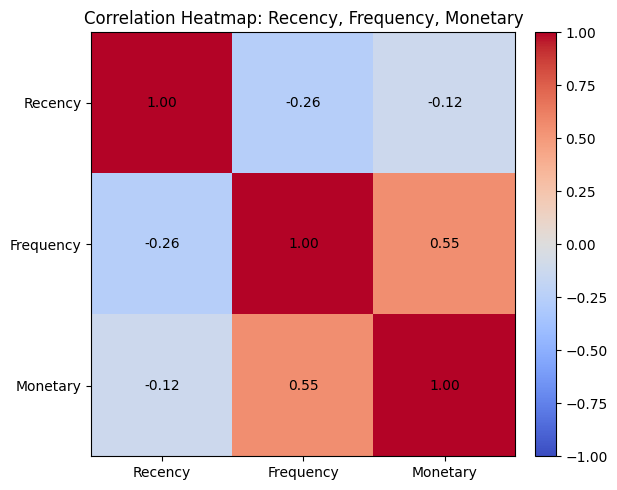

In [40]:
corr_matrix = rfm_viz[["Recency", "Frequency", "Monetary"]].corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(np.arange(corr_matrix.shape[1]))
ax.set_yticks(np.arange(corr_matrix.shape[0]))
ax.set_xticklabels(corr_matrix.columns)
ax.set_yticklabels(corr_matrix.index)
ax.set_title("Correlation Heatmap: Recency, Frequency, Monetary")
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        ax.text(j, i, f"{corr_matrix.iat[i, j]:.2f}", ha="center", va="center", fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

**Key Insight**
- Customers who buy more frequently also tend to generate more revenue, making Frequency a strong value signal for the company.
- Longer inactivity is associated with weaker repeat-purchase behavior, which increases future revenue risk.<br>
-> Marketing action: Trigger early re-engagement campaigns for high-frequency customers as soon as their Recency starts to worsen.

### Chart 6 - Score Matrix Heatmaps
Score matrices show customer density by R-F and average monetary value by R-M in a compact view.

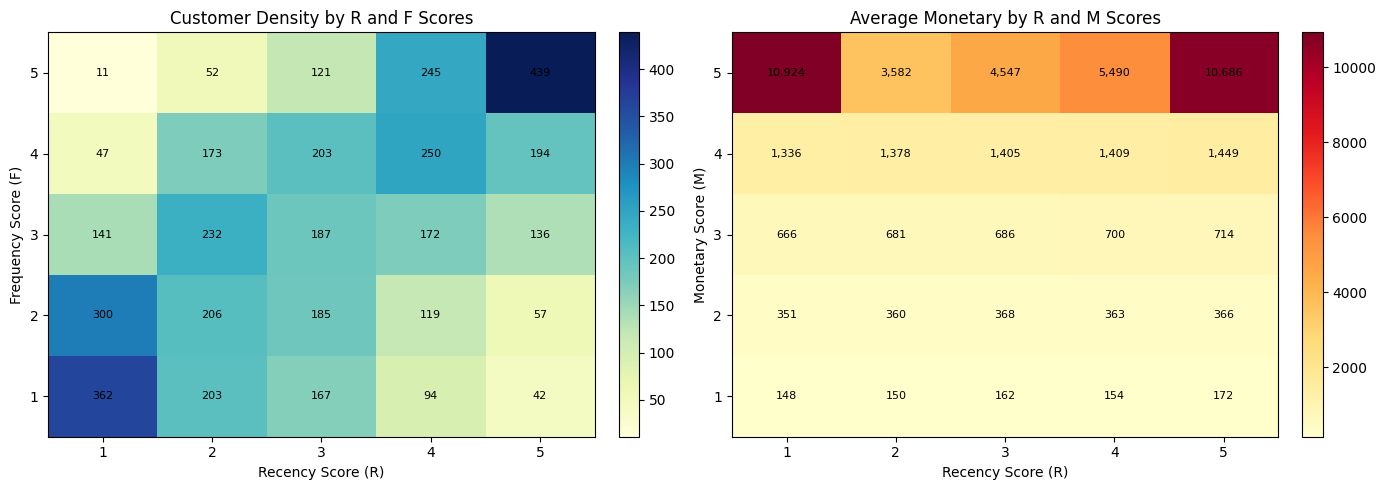

In [41]:
rf_count_matrix = (
    rfm_viz.pivot_table(index="F", columns="R", values="CustomerID", aggfunc="count", fill_value=0)
    .reindex(index=score_levels, columns=score_levels, fill_value=0)
)
rm_value_matrix = (
    rfm_viz.pivot_table(index="M", columns="R", values="Monetary", aggfunc="mean", fill_value=0)
    .reindex(index=score_levels, columns=score_levels, fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
draw_annotated_heatmap(
    axes[0],
    rf_count_matrix,
    "Customer Density by R and F Scores",
    "Recency Score (R)",
    "Frequency Score (F)",
    cmap="YlGnBu",
)
draw_annotated_heatmap(
    axes[1],
    rm_value_matrix,
    "Average Monetary by R and M Scores",
    "Recency Score (R)",
    "Monetary Score (M)",
    cmap="YlOrRd",
)
plt.tight_layout()
plt.show()

**Key Insight**
- The company's core value is concentrated in high-Recency and high-Frequency zones, while low-Recency but high-Monetary zones indicate hidden revenue at risk.
- Different score zones reflect different business states, from stable retention areas to recovery opportunities.<br>
-> Marketing action: Allocate budget by score-zone priority, focusing retention on strong value zones and reactivation on low-Recency but high-potential zones.

### Chart 7 - RFM Segmentation Dimension Map
A dominant-segment map across Recency and FM bands to highlight where each segment is concentrated.

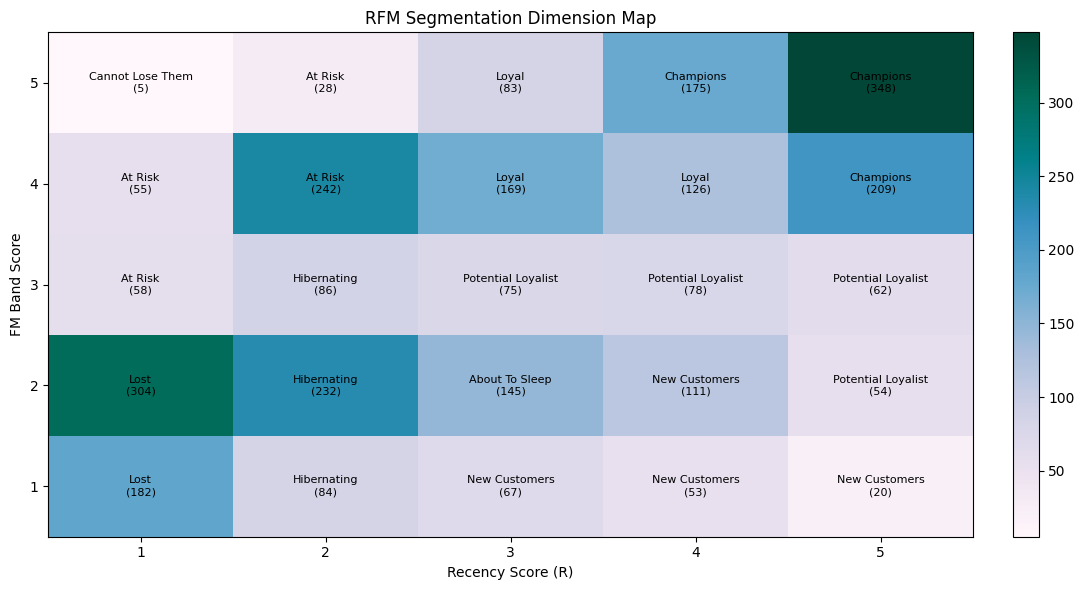

In [42]:
segment_map_source = rfm_viz.copy()
segment_map_source["FM_Band"] = ((segment_map_source["F"] + segment_map_source["M"]) / 2).round().astype(int)

dominant_segment = (
    segment_map_source.groupby(["FM_Band", "R", "Segment"]).size()
    .reset_index(name="Count")
    .sort_values(["FM_Band", "R", "Count"], ascending=[True, True, False])
    .drop_duplicates(subset=["FM_Band", "R"])
)

segment_label_matrix = pd.DataFrame("", index=score_levels, columns=score_levels)
segment_count_matrix = pd.DataFrame(0, index=score_levels, columns=score_levels)
for row in dominant_segment.itertuples(index=False):
    segment_label_matrix.at[row.FM_Band, row.R] = row.Segment
    segment_count_matrix.at[row.FM_Band, row.R] = row.Count

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(segment_count_matrix.values, cmap="PuBuGn", aspect="auto", origin="lower")
ax.set_title("RFM Segmentation Dimension Map")
ax.set_xlabel("Recency Score (R)")
ax.set_ylabel("FM Band Score")
ax.set_xticks(np.arange(len(score_levels)))
ax.set_yticks(np.arange(len(score_levels)))
ax.set_xticklabels(score_levels)
ax.set_yticklabels(score_levels)

for i in range(segment_label_matrix.shape[0]):
    for j in range(segment_label_matrix.shape[1]):
        seg_name = segment_label_matrix.iat[i, j]
        seg_count = segment_count_matrix.iat[i, j]
        if seg_name == "":
            ax.text(j, i, "-", ha="center", va="center", fontsize=9)
        else:
            short_name = seg_name.replace(" customers", "")
            ax.text(j, i, f"{short_name}\n({seg_count})", ha="center", va="center", fontsize=8)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

**Key Insight**
- Champions and Loyal customers dominate the strongest Recency and FM areas, which marks the healthiest part of the company's customer portfolio.
- At Risk, Lost, and Hibernating segments cluster in weaker Recency zones, revealing visible churn pressure.<br>
-> Marketing action: Build separate playbooks by zone, using loyalty rewards for strong zones and recovery programs for weak-Recency zones.

### Chart 8 - Segment Share by Customers and Revenue
Compare customer share and revenue share to detect segments that are large but low-yield, or small but highly valuable.

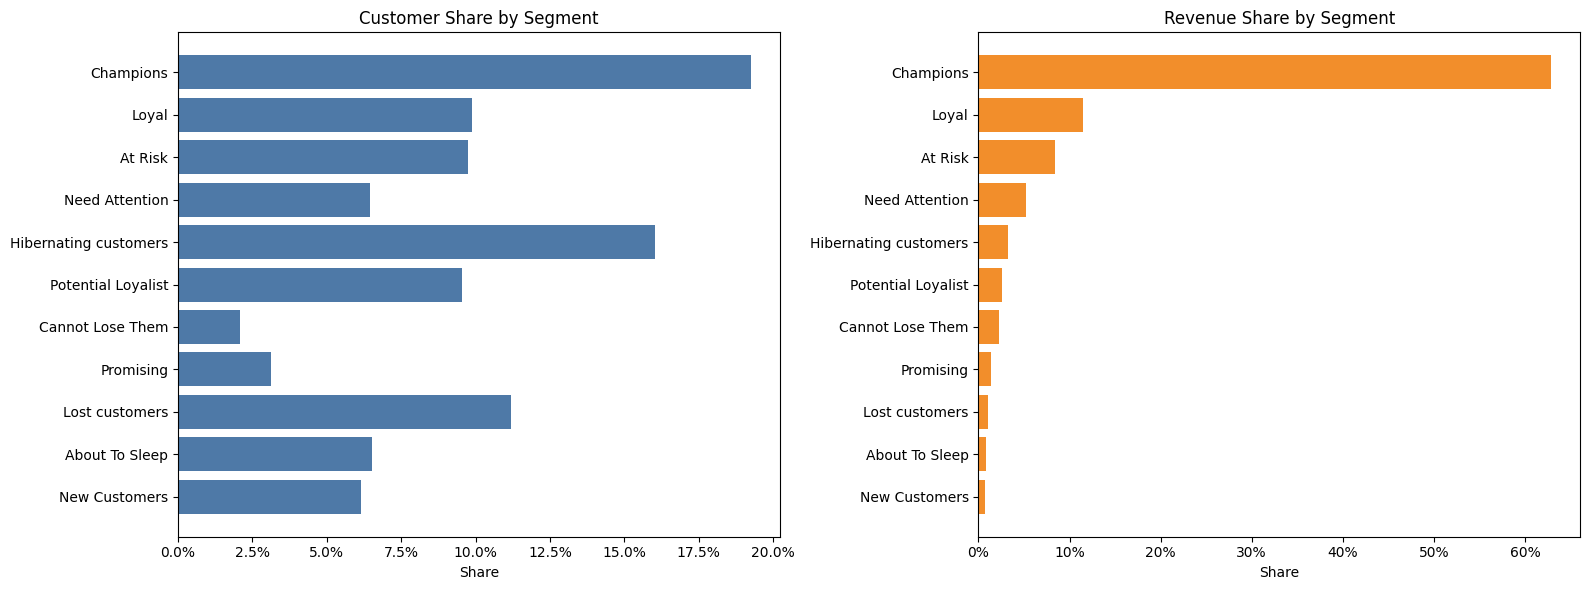

In [43]:
segment_summary = rfm_viz.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    Revenue=("Monetary", "sum"),
    AvgRecency=("Recency", "mean"),
    AvgFrequency=("Frequency", "mean"),
    AvgMonetary=("Monetary", "mean"),
).sort_values("Revenue", ascending=False)

segment_summary["CustomerShare"] = segment_summary["Customers"] / segment_summary["Customers"].sum()
segment_summary["RevenueShare"] = segment_summary["Revenue"] / segment_summary["Revenue"].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(segment_summary.index, segment_summary["CustomerShare"], color="#4E79A7")
axes[0].set_title("Customer Share by Segment")
axes[0].set_xlabel("Share")
axes[0].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].invert_yaxis()

axes[1].barh(segment_summary.index, segment_summary["RevenueShare"], color="#F28E2B")
axes[1].set_title("Revenue Share by Segment")
axes[1].set_xlabel("Share")
axes[1].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**Key Insight**
- The largest segment by customer count is not always the largest by revenue, so customer volume alone does not represent business value.
- Some segments monetize their customer base much more efficiently than others.<br>
-> Marketing action: Use revenue share as the primary budget-prioritization signal, and use customer share to identify scaling opportunities.

### Chart 9 - Pareto Revenue by Segment
Pareto analysis to identify the small number of segments that contribute the majority of revenue.

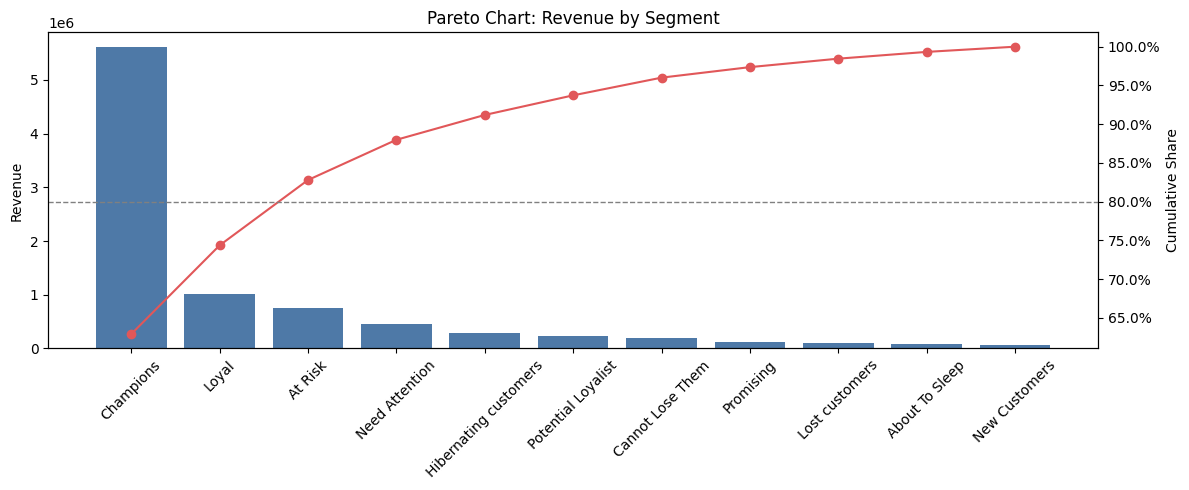

In [44]:
pareto_revenue = segment_summary["Revenue"].sort_values(ascending=False)
cum_share = pareto_revenue.cumsum() / pareto_revenue.sum()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(pareto_revenue.index, pareto_revenue.values, color="#4E79A7")
ax1.set_ylabel("Revenue")
ax1.set_title("Pareto Chart: Revenue by Segment")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(pareto_revenue.index, cum_share.values, color="#E15759", marker="o")
ax2.set_ylabel("Cumulative Share")
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.axhline(0.8, color="gray", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

**Key Insight**
- A small number of segments contribute most of the company's revenue, so business performance is highly concentrated.
- Lower-ranked segments contribute marginal revenue and should not consume the same level of budget intensity.<br>
-> Marketing action: Protect the top revenue-driving segments first, and manage long-tail segments with low-cost automated campaigns.

### Chart 10 - Behavior Bubble Chart (Recency vs Monetary, Bubble = Frequency)
Three-dimensional customer behavior view to identify high-value clusters and segments with churn risk.

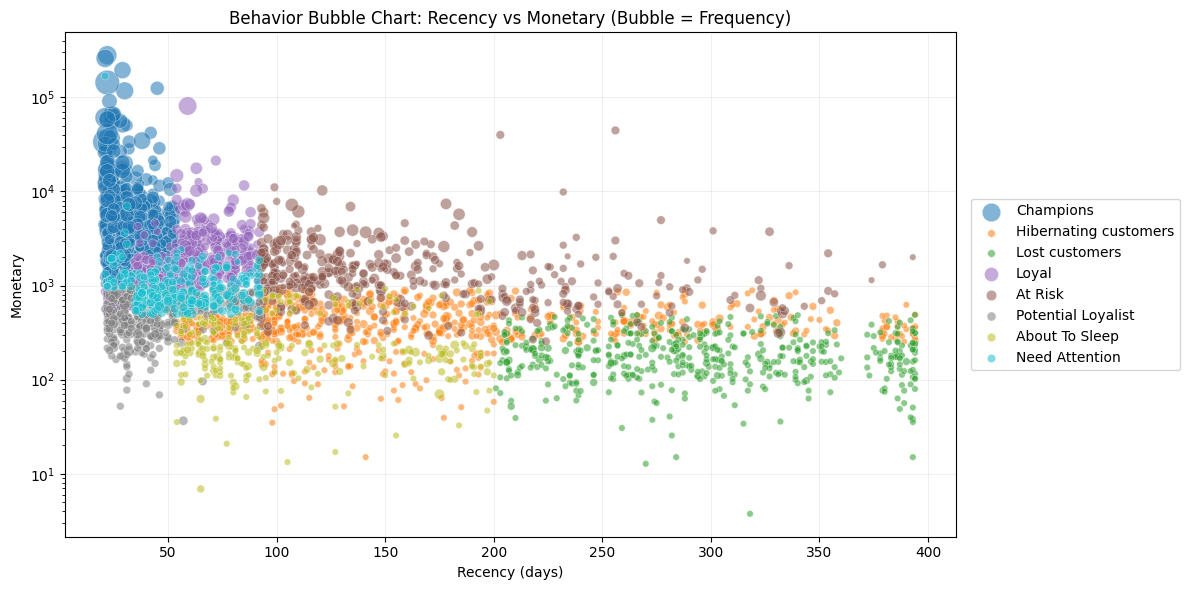

In [45]:
top_segments = rfm_viz["Segment"].value_counts().head(8).index
bubble_df = rfm_viz[rfm_viz["Segment"].isin(top_segments)].copy()
palette = plt.cm.tab10(np.linspace(0, 1, len(top_segments)))

fig, ax = plt.subplots(figsize=(12, 6))
for color, seg in zip(palette, top_segments):
    subset = bubble_df[bubble_df["Segment"] == seg]
    bubble_size = np.sqrt(subset["Frequency"]).clip(lower=1) * 22
    ax.scatter(
        subset["Recency"],
        subset["Monetary"],
        s=bubble_size,
        alpha=0.55,
        color=color,
        label=seg,
        edgecolors="white",
        linewidths=0.4,
    )

ax.set_title("Behavior Bubble Chart: Recency vs Monetary (Bubble = Frequency)")
ax.set_xlabel("Recency (days)")
ax.set_ylabel("Monetary")
ax.set_yscale("log")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**Key Insight**
- Some customer clusters still generate high Monetary value even when Recency worsens, meaning the company has valuable customers at immediate churn risk.
- Large bubbles indicate segments with stronger purchase habits and higher loyalty potential.<br>
-> Marketing action: Launch rapid win-back offers for high-value inactive clusters and loyalty-tier programs for high-frequency clusters.

### Chart 11 - Segment Profile Heatmap (Normalized)
Normalized segment profile heatmap to compare the relative strengths and weaknesses of each segment across average Recency, Frequency, and Monetary.

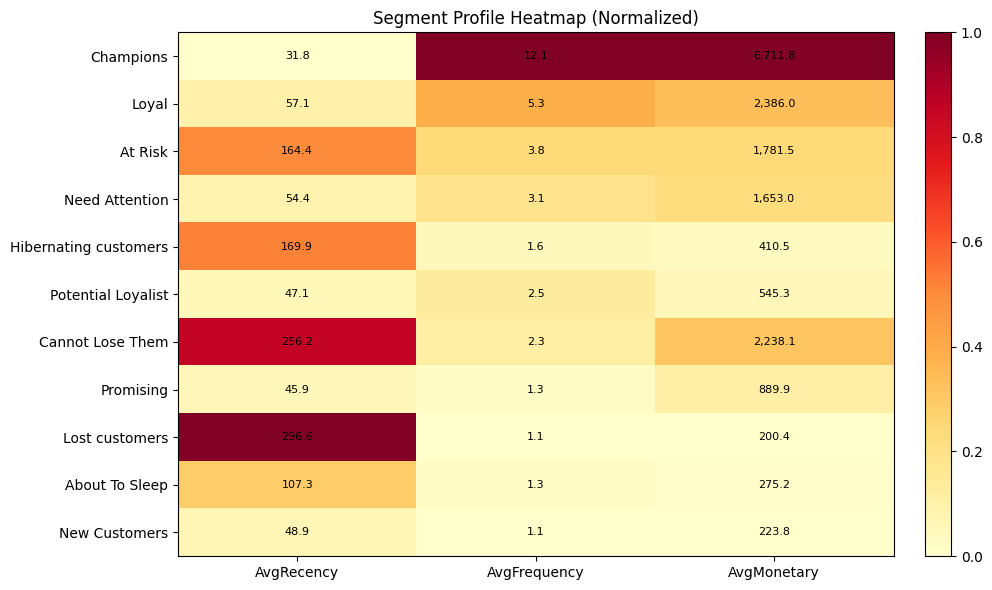

In [46]:
if "segment_summary" not in globals():
    segment_summary = rfm_viz.groupby("Segment").agg(
        Customers=("CustomerID", "count"),
        Revenue=("Monetary", "sum"),
        AvgRecency=("Recency", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgMonetary=("Monetary", "mean"),
    ).sort_values("Revenue", ascending=False)

profile = segment_summary[["AvgRecency", "AvgFrequency", "AvgMonetary"]].copy()
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())
profile_norm = profile_norm.fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(profile_norm.values, cmap="YlOrRd", aspect="auto")
ax.set_title("Segment Profile Heatmap (Normalized)")
ax.set_xticks(np.arange(profile_norm.shape[1]))
ax.set_yticks(np.arange(profile_norm.shape[0]))
ax.set_xticklabels(profile_norm.columns)
ax.set_yticklabels(profile_norm.index)
for i in range(profile.shape[0]):
    for j in range(profile.shape[1]):
        ax.text(j, i, f"{profile.iat[i, j]:,.1f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

**Key Insight**
- Segment profiles show clear behavioral gaps between high-value customers and dormant customers, so the company is managing very different customer states.
- A single KPI framework is not appropriate for all segments because their value patterns and lifecycle stages differ materially.<br>
-> Marketing action: Set segment-specific KPI targets and lifecycle-movement goals, such as moving Hibernating customers into active mid-value segments.

### Chart 12 - Monthly Revenue Trend by Top Segments
Monthly revenue trend for the top-performing segments to detect seasonality and identify the best timing for campaigns.

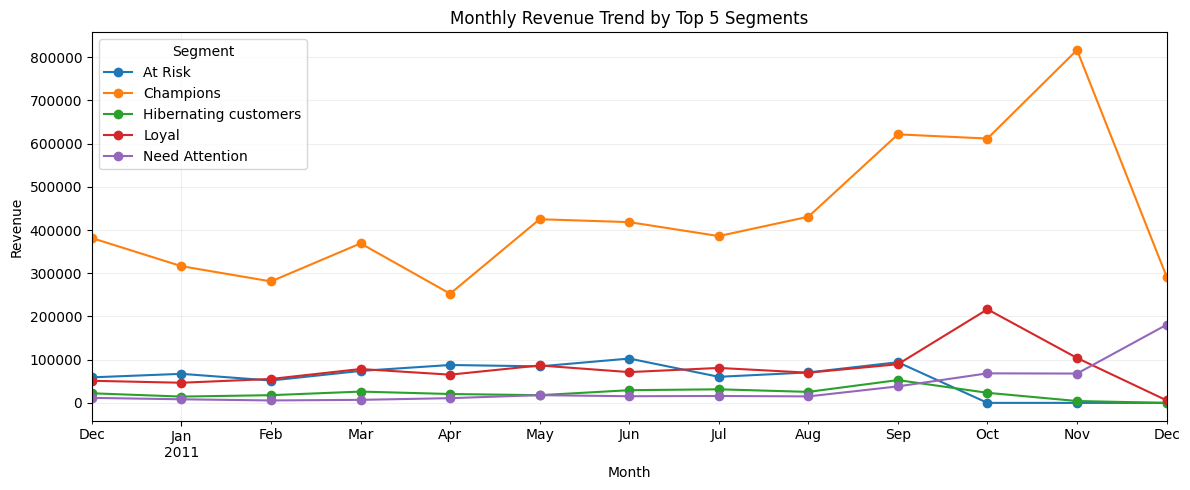

In [47]:
if "Revenue" not in ecommerce_retail.columns:
    ecommerce_retail["Revenue"] = ecommerce_retail["Quantity"] * ecommerce_retail["UnitPrice"]

monthly_df = ecommerce_retail.copy()
monthly_df["Segment"] = monthly_df["CustomerID"].map(rfm.set_index("CustomerID")["Segment"]).fillna("Others")
monthly_df["InvoiceMonth"] = monthly_df["InvoiceDate"].dt.to_period("M").dt.to_timestamp()

top_revenue_segments = monthly_df.groupby("Segment")["Revenue"].sum().nlargest(5).index
monthly_trend = (
    monthly_df[monthly_df["Segment"].isin(top_revenue_segments)]
    .groupby(["InvoiceMonth", "Segment"])["Revenue"]
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

monthly_trend.plot(figsize=(12, 5), marker="o")
plt.title("Monthly Revenue Trend by Top 5 Segments")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**Key Insight**
- Revenue from top segments changes over time, which means the business is exposed to seasonal peaks and slowdown periods.
- Some segments appear more stable while others are more volatile, creating different planning requirements for the company.<br>
-> Marketing action: Time campaigns ahead of seasonal peaks and trigger retention interventions quickly when a key segment shows consecutive decline.

## **7) Recommendation for Marketing and Sales**
Based on all Key Insights above, **Frequency (F)** should receive the highest priority in this retail business context.

**Why Frequency (F) is the top priority**
- Frequency has the clearest link to revenue generation: customers who buy more often also contribute more monetary value.
- High-performing segments (such as Champions and Loyal) are consistently defined by strong repeat-purchase behavior.
- Improving purchase frequency creates more stable and scalable growth than relying on occasional high-ticket orders.

**Role of the other two metrics**
- **Recency (R)** should be used as an early-warning trigger to protect Frequency. When Recency worsens, re-engagement must be activated quickly.
- **Monetary (M)** should be treated as an outcome KPI that improves after Frequency and Recency programs are executed well.

**Recommended priority order**
1. **Frequency (F)** - Main growth lever
2. **Recency (R)** - Retention/risk control trigger
3. **Monetary (M)** - Result metric to monitor value capture

**Marketing and Sales execution rule**
-> Marketing action: Set Frequency growth as the primary target, trigger automated win-back when Recency declines, and track Monetary uplift at segment level as the final performance outcome.